# 02. Model Comparison

## Question
**어떤 이상탐지 모델이 사기 거래 탐지에 가장 적합한가?**

## Objective
Isolation Forest, AutoEncoder, Elliptic Envelope 등의 탐지 성능을 비교하고
최종 모델을 선정한다.

In [25]:
train_x = train_df.drop(columns = ["ID"]).copy()
val_x = val_df.drop(columns = ["ID", "Class"]).copy()
val_y = val_df["Class"].copy()
test_x = test_df.drop(columns = ["ID"]).copy()

print("train_x shape: ", train_x.shape)
print("val_x shape: ", val_x.shape)
print("val_y shape :", val_y.shape)
print("test_x shape :", test_x.shape)

train_x shape:  (113842, 30)
val_x shape:  (28462, 30)
val_y shape : (28462,)
test_x shape : (142503, 30)


In [26]:
# 예측 결과 변환 함수
# 비지도 모델은 정상 = 1, 이상 = -1을 내놓는 경우가 많으므로 정상 = 0, 사기 = 1로 출력함수 생성
# 알아야할 데이터가 사기이기 때문에 사기를 1로 생성함.
def get_pred_label(model_pred):
    model_pred = np.where(model_pred == 1, 0, model_pred) # 정상 = 1, 이상치는 -1 => 정상 = 0, 사기 = 1로 변환
    model_pred = np.where(model_pred == -1, 1, model_pred)
    return model_pred

In [27]:
def evaluate_model(y_true, y_pred, model_name = "model"):
    precision = precision_score(y_true, y_pred, zero_division = 0)
    recall = recall_score(y_true, y_pred, zero_division = 0)
    f1 = f1_score(y_true, y_pred, zero_division = 0)

    print(f"\n[{model_name}]")
    print("Precision: ", round(precision, 4))
    print("Recall: ", round(recall, 4))
    print("F1-score: ", round(f1, 4))
    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division = 0))
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize = (5, 4))

    main_color = "#00695C"
    sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(main_color, as_cmap=True), 
                cbar=False, annot_kws={"size": 14, "weight": "bold"})
    plt.title(f'Confusion Matrix: {model_name}', fontsize=14, pad=20)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.show()

    return {"model" : model_name
    , "precision" : precision
    , "recall" : recall
    , "f1" : f1
           }

<Axes: xlabel='V17', ylabel='V14'>

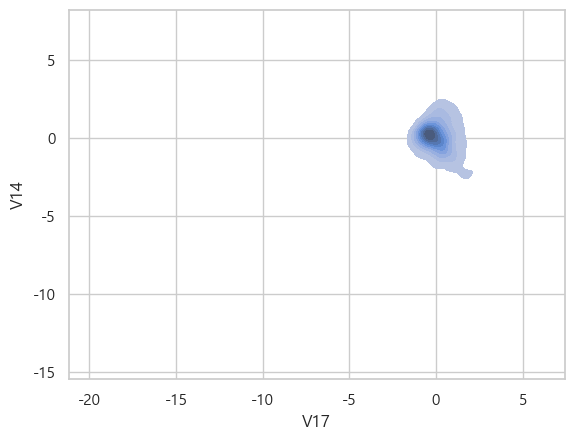

In [28]:
sns.kdeplot(x=val_x["V17"], y=val_x["V14"], fill=True)

In [29]:
cov = np.cov(val_x[val_y==0].T)
eigvals = np.linalg.eigvalsh(cov)
print(eigvals.max() / eigvals.min())
# 이 비율이 1에 가까우면 원형(구형)에 가깝고, 훨씬 크면 한쪽으로 길쭉한 타원형

173.2580881850387


# Model Comparison

In [30]:
# 스케일링 적용
robust_scaler = RobustScaler()
train_x_robust = robust_scaler.fit_transform(train_x)
val_x_robust = robust_scaler.transform(val_x)

standard_scaler = StandardScaler()
train_x_standard = standard_scaler.fit_transform(train_x)
val_x_standard = standard_scaler.transform(val_x)

minmax_scaler = MinMaxScaler()
train_x_minmax = minmax_scaler.fit_transform(train_x)
val_x_minmax = minmax_scaler.transform(val_x)

In [31]:
scalers = {
    "none" : None
    , "standard" : StandardScaler()
    , "minmax" : MinMaxScaler()
    , "robust" : RobustScaler()
}

In [33]:
# 스케일링 적용 함수
def apply_scaler(train_x, val_x, scaler_obj):
    if scaler_obj is None:
        return train_x.values, val_x.values

    train_scaled = scaler_obj.fit_transform(train_x)
    val_scaled = scaler_obj.transform(val_x)

    return train_scaled, val_scaled

In [34]:
def calc_metrics(y_true, y_pred):
    return {"precision" : precision_score(y_true, y_pred, zero_division = 0)
            , "recall" : recall_score(y_true, y_pred, zero_division = 0)
            , "f1" : f1_score(y_true, y_pred, zero_division = 0)
           }

In [39]:
def anomaly_search(model_class, model_name, train_x, val_x, val_y, param_grid, scalers=None, model_kwargs=None):

    # 기본 스케일러
    if scalers is None:
        scalers = {
            "none": None,
            "standard": StandardScaler(),
            "minmax": MinMaxScaler(),
            "robust": RobustScaler()
        }

    if model_kwargs is None:
        model_kwargs = {}

    results = []

    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())

    total = (len(scalers) * len(list(product(*param_values))))

    with tqdm(total=total, desc=f"{model_name} Search") as pbar:
        for scaler_name, scaler_obj in scalers.items():
            train_scaled, val_scaled = apply_scaler(train_x, val_x, scaler_obj)

            for values in product(*param_values):
                params = dict(zip(param_names, values))

                try:
                    model = model_class(**params, **model_kwargs)
                    model.fit(train_scaled)

                    pred = model.predict(val_scaled)
                    pred = get_pred_label(pred)

                    metrics = calc_metrics(val_y, pred)

                    results.append({
                        "model": model_name,
                        "scaler": scaler_name,
                        **params,
                        **metrics
                    })

                except Exception as e:

                    print(e)

                    results.append({
                        "model": model_name,
                        "scaler": scaler_name,
                        **params,
                        "precision": None,
                        "recall": None,
                        "f1": None,
                        "error": str(e)
                    })

                pbar.update(1)

    return pd.DataFrame(results)

In [40]:
# 1. IsolationForest
if_param_grid = {
    "contamination": np.linspace(0.001, 0.005, 11)
    , "n_estimators": [100, 150, 200]
    , "max_samples": ['auto', 0.7, 0.8, 0.9]
}

if_results = anomaly_search(
    model_class = IsolationForest
    , model_name = "IsolationForest"
    , train_x = train_x
    , val_x = val_x
    , val_y = val_y
    , param_grid = if_param_grid
    , model_kwargs = {"random_state" : 42, "n_jobs" : -1}
)

if_results.sort_values("f1", ascending=False).head(10)

IsolationForest Search: 100%|████████████████████████████████████████████████████████| 528/528 [41:04<00:00,  4.67s/it]


,model,scaler,contamination,n_estimators,max_samples,precision,recall,f1
33,IsolationForest,none,0.0018,200,0.7,0.380952,0.533333,0.444444
29,IsolationForest,none,0.0018,150,0.7,0.380952,0.533333,0.444444
297,IsolationForest,minmax,0.0018,200,0.7,0.380952,0.533333,0.444444
293,IsolationForest,minmax,0.0018,150,0.7,0.380952,0.533333,0.444444
161,IsolationForest,standard,0.0018,150,0.7,0.380952,0.533333,0.444444
165,IsolationForest,standard,0.0018,200,0.7,0.380952,0.533333,0.444444
425,IsolationForest,robust,0.0018,150,0.7,0.380952,0.533333,0.444444
429,IsolationForest,robust,0.0018,200,0.7,0.380952,0.533333,0.444444
435,IsolationForest,robust,0.0022,100,0.9,0.340000,0.566667,0.425000
303,IsolationForest,minmax,0.0022,100,0.9,0.340000,0.566667,0.425000



[Final IsolationForest]
Precision:  0.381
Recall:  0.5333
F1-score:  0.4444

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.38      0.53      0.44        30

    accuracy                           1.00     28462
   macro avg       0.69      0.77      0.72     28462
weighted avg       1.00      1.00      1.00     28462



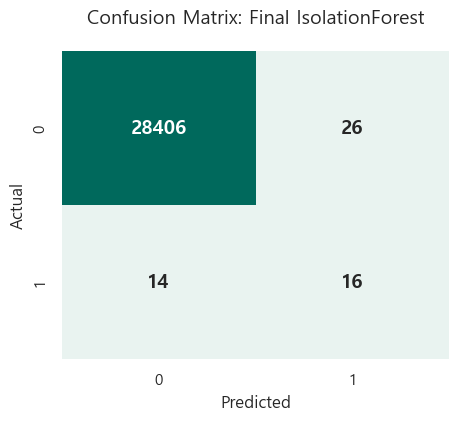

In [41]:
best_if = IsolationForest(n_estimators = 200, max_samples = 0.7, contamination = 0.0018, random_state = 42)
best_if.fit(train_x)

best_pred_if= best_if.predict(val_x)
best_pred_if = get_pred_label(best_pred_if)
best_result_if = evaluate_model(val_y, best_pred_if, "Final IsolationForest")

In [121]:
#  2. EllipticEnvelope
ee_param_grid = {
    "contamination": np.linspace(0.001, 0.002, 11)
    , "support_fraction": [0.990, 0.992, 0.994, 0.996, 0.998]
}

ee_results = anomaly_search(
    model_class = EllipticEnvelope
    , model_name = "EllipticEnvelope"
    , train_x = train_x
    , val_x = val_x
    , val_y = val_y
    , param_grid = ee_param_grid
    , model_kwargs = {"random_state" : 42}
)

ee_results.sort_values("f1", ascending=False).head(10)

EllipticEnvelope Search: 100%|████████████████████████████████████████████████████| 220/220 [6:14:49<00:00, 102.23s/it]


,model,scaler,contamination,support_fraction,precision,recall,f1
129,EllipticEnvelope,minmax,0.0013,0.998,0.833333,0.833333,0.833333
17,EllipticEnvelope,none,0.0013,0.994,0.833333,0.833333,0.833333
67,EllipticEnvelope,standard,0.0012,0.994,0.833333,0.833333,0.833333
72,EllipticEnvelope,standard,0.0013,0.994,0.833333,0.833333,0.833333
73,EllipticEnvelope,standard,0.0013,0.996,0.833333,0.833333,0.833333
74,EllipticEnvelope,standard,0.0013,0.998,0.833333,0.833333,0.833333
177,EllipticEnvelope,robust,0.0012,0.994,0.833333,0.833333,0.833333
178,EllipticEnvelope,robust,0.0012,0.996,0.833333,0.833333,0.833333
179,EllipticEnvelope,robust,0.0012,0.998,0.833333,0.833333,0.833333
182,EllipticEnvelope,robust,0.0013,0.994,0.833333,0.833333,0.833333


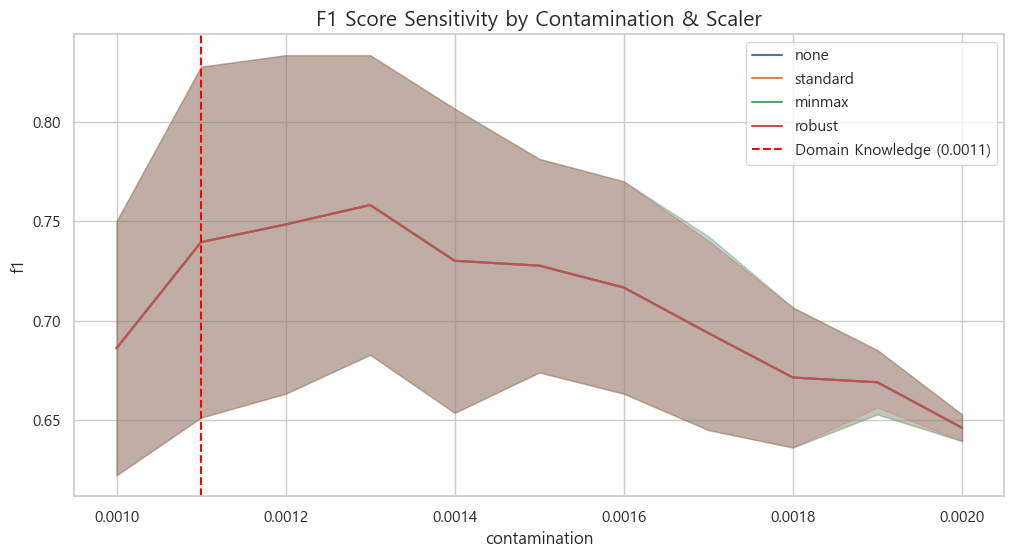

In [123]:
# contamination 변화에 따른 Scaler 별 성능
plt.figure(figsize = (12, 6))
sns.lineplot(data = ee_results, x = "contamination", y = "f1", hue = "scaler")
plt.title('F1 Score Sensitivity by Contamination & Scaler', fontsize=15)
plt.axvline(x = 0.0011, color='red', linestyle='--', label='Domain Knowledge (0.0011)')
plt.legend()
plt.show()


[Final Elliptic]
Precision:  0.8333
Recall:  0.8333
F1-score:  0.8333

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.83      0.83      0.83        30

    accuracy                           1.00     28462
   macro avg       0.92      0.92      0.92     28462
weighted avg       1.00      1.00      1.00     28462



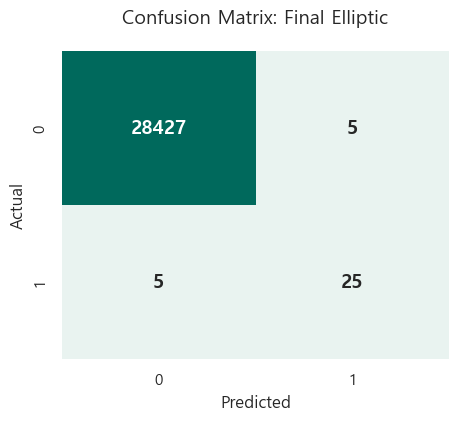

In [42]:
best_ee = EllipticEnvelope(contamination = 0.0013, support_fraction = 0.994, random_state = 42)
best_ee.fit(train_x)

best_pred = best_ee.predict(val_x)
best_pred = get_pred_label(best_pred)
best_result_ee = evaluate_model(val_y, best_pred, "Final Elliptic")

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof_param_grid = {
    "contamination":[0.0005,0.001,0.002],
    "n_neighbors":[10,20,30],
    "novelty":[True]
}

lof_results = anomaly_search(
    model_class=LocalOutlierFactor,
    model_name="LOF",
    train_x=train_x,
    val_x=val_x,
    val_y=val_y,
    param_grid=lof_param_grid
)

In [44]:
lof_results.sort_values("f1", ascending=False).head(10)

,model,scaler,contamination,n_neighbors,novelty,precision,recall,f1
26,LOF,minmax,0.0020,30,True,0.085714,0.200000,0.120000
25,LOF,minmax,0.0020,20,True,0.049383,0.133333,0.072072
32,LOF,robust,0.0010,30,True,0.062500,0.066667,0.064516
35,LOF,robust,0.0020,30,True,0.035714,0.066667,0.046512
23,LOF,minmax,0.0010,30,True,0.033333,0.033333,0.033333
22,LOF,minmax,0.0010,20,True,0.025641,0.033333,0.028986
24,LOF,minmax,0.0020,10,True,0.019231,0.033333,0.024390
34,LOF,robust,0.0020,20,True,0.018519,0.033333,0.023810
17,LOF,standard,0.0020,30,True,0.018182,0.033333,0.023529
19,LOF,minmax,0.0005,20,True,0.000000,0.000000,0.000000


In [37]:
ocsvm_param_grid = {
    "kernel":["rbf"],
    "gamma":["scale",0.001,0.01],
    "nu":[0.001,0.005,0.01]
}

ocsvm_results = anomaly_search(
    model_class=OneClassSVM,
    model_name="OneClassSVM",
    train_x=train_x,
    val_x=val_x,
    val_y=val_y,
    param_grid=ocsvm_param_grid
)

OneClassSVM Search: 100%|██████████████████████████████████████████████████████████████| 36/36 [27:09<00:00, 45.26s/it]


In [38]:
ocsvm_results.sort_values("f1", ascending=False).head(10)

,model,scaler,kernel,gamma,nu,precision,recall,f1
18,OneClassSVM,minmax,rbf,scale,0.001,0.352941,0.400000,0.375000
24,OneClassSVM,minmax,rbf,0.01,0.001,0.322581,0.333333,0.327869
21,OneClassSVM,minmax,rbf,0.001,0.001,0.322581,0.333333,0.327869
12,OneClassSVM,standard,rbf,0.001,0.001,0.266667,0.266667,0.266667
3,OneClassSVM,none,rbf,0.001,0.001,0.259259,0.233333,0.245614
19,OneClassSVM,minmax,rbf,scale,0.005,0.140741,0.633333,0.230303
4,OneClassSVM,none,rbf,0.001,0.005,0.138462,0.600000,0.225000
25,OneClassSVM,minmax,rbf,0.01,0.005,0.124138,0.600000,0.205714
22,OneClassSVM,minmax,rbf,0.001,0.005,0.122449,0.600000,0.203390
16,OneClassSVM,standard,rbf,0.01,0.005,0.120805,0.600000,0.201117


In [49]:
# autoencoder

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
#tf.keras.utils.set_random_seed(42)

def build_autoencoder(input_dim, bottleneck):
    model = models.Sequential([
        layers.Input(shape = (input_dim,))
        , layers.Dense(bottleneck * 2, activation = "relu")
        , layers.Dense(bottleneck, activation = "relu")
        , layers.Dense(bottleneck * 2, activation = "relu")
        , layers.Dense(input_dim, activation = "linear")
    ])

    model.compile(optimizer = "adam", loss = "mse")

    return model

In [50]:
def autoencoder_search(train_x, val_x, val_y, param_grid, contaminations, scalers = None):
    if scalers is None:
        scalers = {
            "none": None
            , "minmax" : MinMaxScaler()
        }

    input_dim = train_x.shape[1]

    results = []

    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())

    total = len(scalers) * len(list(product(*param_values))) * len(contaminations)

    with tqdm(total = total, desc = "AutoEncoder Search") as pbar:
        for scaler_name, scaler_obj in scalers.items():
            train_scaled, val_scaled = apply_scaler(train_x, val_x, scaler_obj)

            for values in product(*param_values):
                params = dict(zip(param_names, values))

                try:
                    random.seed(42)
                    np.random.seed(42)
                    tf.random.set_seed(42)
                    
                    model = build_autoencoder(
                        input_dim = input_dim
                        , bottleneck = params["bottleneck"]
                    )

                    model.fit(train_scaled, train_scaled, epochs = params["epochs"], batch_size = params["batch_size"], verbose = 0)
                    pred = model.predict(val_scaled, verbose = 0)
                    mse = np.mean(np.square(val_scaled - pred), axis = 1)

                    for contamination in contaminations:
                    
                        threshold = np.percentile(mse, (1 - contamination) * 100)
                        pred_label = (mse >= threshold).astype(int)
                    
                        metrics = calc_metrics(val_y, pred_label)
                    
                        results.append({
                            "model": "AutoEncoder",
                            "scaler": scaler_name,
                            **params,
                            "contamination": contamination,
                            **metrics
                        })
                    
                        pbar.update(1)
                        
                except Exception as e:
                    results.append({
                        "model" : "AutoEncoder"
                        , "scaler" : scaler_name
                        , **params
                        , "precision" : None
                        , "recall" : None
                        , "f1" : None
                        , "error" : str(e)
                    })

                    pbar.update(len(contaminations))

    return pd.DataFrame(results)


[Final AutoEncoder]
Precision:  0.5862
Recall:  0.5667
F1-score:  0.5763

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.59      0.57      0.58        30

    accuracy                           1.00     28462
   macro avg       0.79      0.78      0.79     28462
weighted avg       1.00      1.00      1.00     28462



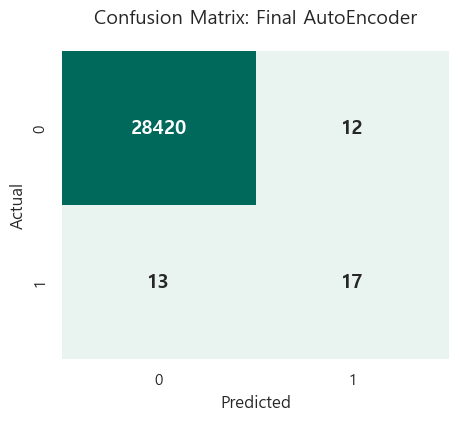

{'model': 'Final AutoEncoder',
 'precision': 0.5862068965517241,
 'recall': 0.5666666666666667,
 'f1': 0.576271186440678}

In [52]:
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

minmax_scaler = MinMaxScaler()

train_x_minmax = minmax_scaler.fit_transform(train_x)
val_x_minmax = minmax_scaler.transform(val_x)

# autoencoder 생성
best_ae = build_autoencoder(input_dim = train_x_minmax.shape[1], bottleneck = 8)
    
# 학습
best_ae.fit(train_x_minmax, train_x_minmax, epochs = 50, batch_size = 256, verbose = 0)

preds = best_ae.predict(val_x_minmax, verbose = 0)
mse = np.mean(np.power(val_x_minmax - preds, 2), axis = 1)

# threshold
contamination = 0.0010
thresh = np.percentile(mse, (1 - contamination) * 100)

best_pred = np.where(mse >= thresh, 1, 0)

best_result_ae = evaluate_model(val_y, best_pred, "Final AutoEncoder")
best_result_ae

In [59]:
# 1. Anomaly Score 계산 (이상치일수록 높은 양수)
ee_scores = best_ee.decision_function(val_x)
anomaly_scores = -ee_scores

score_ee_df = pd.DataFrame({"y_true" : val_y.values, "scores" : anomaly_scores})

# 2. 이상치 스케일을 통제하기 위해 상위 99.9% 지점을 max_val로 설정
min_val = score_ee_df["scores"].min()
max_val = score_ee_df["scores"].quantile(0.999)

# 3. Min-Max Scaling 적용 후 0~100 사이로 캡핑(np.clip)
score_ee_df["scaled_score"] = (
    (score_ee_df["scores"] - min_val) / (max_val - min_val) * 100
)
score_ee_df["scaled_score"] = score_ee_df["scaled_score"].clip(0, 100)
score_ee_df.head()

,y_true,scores,scaled_score
0,0,-432692.996181,0.000499
1,0,-432671.973327,0.001095
2,0,-432695.657515,0.000423
3,0,-432680.009482,0.000867
4,0,-431970.324030,0.021007


### Risk Score Scaling
- `decision_function`은 값이 클수록 정상, 작을수록 이상을 의미하므로 부호를 반전해 **높을수록 위험한 방향**으로 변환
- 해석이 어려운 원점수 범위를 0~100의 Risk Score로 변환하기 위해 Min-Max Scaling을 적용
- 이때 극단적인 이상치 하나가 전체 스케일을 왜곡하는 것을 방지하기 위해 실제 최댓값 대신 **99.9% Quantile을 상한값으로 설정**
- 99%와 99.9% Quantile을 비교한 결과, 99%에서는 더 많은 정상 거래가 100점에 집중되어 FP가 증가하고 비용 기반 성능이 저하됨. -> 최종 Risk Score에는 99.9% Quantile을 적용

> 단, Quantile 기준은 Validation 데이터의 성능을 참고해 선택했기 때문에 완전히 비지도적인 설정은 아님

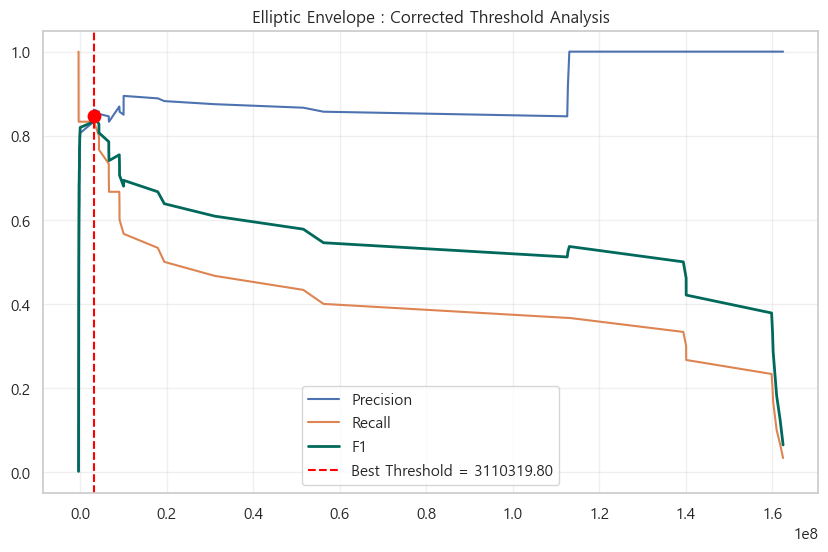

In [60]:
# trade-off 그래프

precision, recall, thresholds = precision_recall_curve(val_y, anomaly_scores)
f1_scores = 2 * (precision * recall) / (precision + recall)

plt.figure(figsize = (10, 6))
plt.plot(thresholds, precision[:-1], label = "Precision")
plt.plot(thresholds, recall[:-1], label = "Recall")
plt.plot(thresholds, f1_scores[:-1], label = "F1", color = "#00695C", lw = 2)

best_idx = np.argmax(f1_scores[:-1])

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best Threshold = {best_threshold:.2f}")

plt.scatter(best_threshold, best_f1, color="red", s=80, zorder=5)

plt.title("Elliptic Envelope : Corrected Threshold Analysis")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

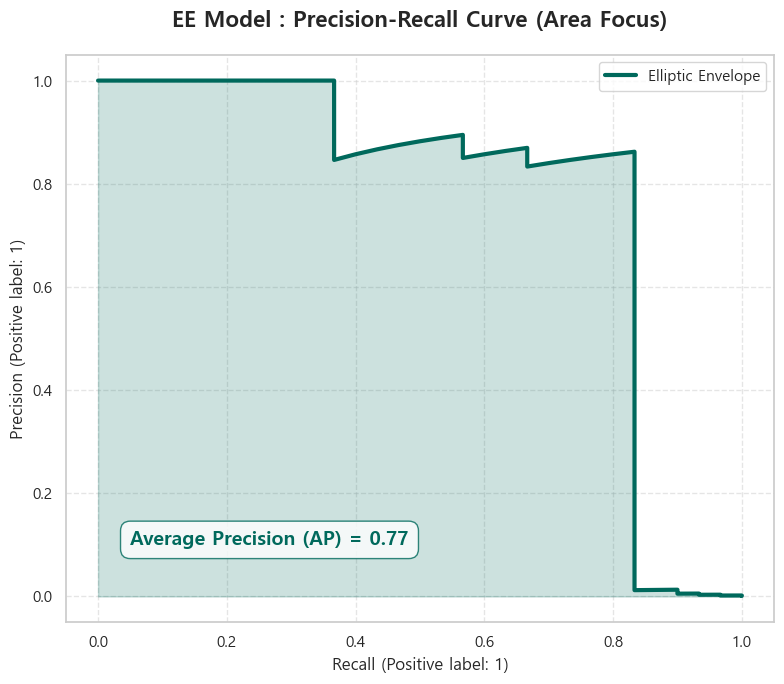

In [61]:
ap_score = average_precision_score(val_y, anomaly_scores)

plt.figure(figsize = (8, 7))

plt.plot(recall, precision, color = "#00695C", lw = 3, label = f"Elliptic Envelope")
plt.fill_between(recall, precision, alpha = 0.2, color = "#00695C")

plt.text(0.05, 0.1, f"Average Precision (AP) = {ap_score:.2f}"
         , fontsize = 14, fontweight = "bold", color = "#00695C"
         , bbox = dict(facecolor = "white", alpha = 0.8, edgecolor = "#00695C", boxstyle = "round,pad=0.5"))

plt.title("EE Model : Precision-Recall Curve (Area Focus)", fontsize = 16, fontweight = "bold", pad = 20)
plt.xlabel("Recall (Positive label: 1)", fontsize = 12)
plt.ylabel("Precision (Positive label: 1)", fontsize = 12)
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.legend(loc = "upper right")

plt.tight_layout()
plt.show()